<a href="https://colab.research.google.com/github/Miclanche/colab-git-assignment2-MA/blob/main/Assignment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---

*Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



# README

## Project Title
Amazon Alexa Sentiment Analysis

## Objective
Classify reviews as positive or negative using Random Forest

## Files Included
- Lesson_10_assignment.ipynb

## How to Run
1. Open the notebook in Google Colab
2. Run all cells in order
3. Modify the review text at the bottom to test predictions

## Requirements
- Python
- scikit-learn
- pandas
- seaborn


In [2]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules

import pandas as pd
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("sid321axn/amazon-alexa-reviews")

# Check what files are inside
print(os.listdir(path))

# Load CSV (correct file path)
file_path = os.path.join(path, "amazon_alexa.tsv")
df = pd.read_csv(file_path, sep="\t")

# Preview data
print(df.head())

#Inspect data types and statistical properties.

print(df.info())

print(df.describe())


100%|██████████| 164k/164k [00:00<00:00, 703kB/s]

Extracting files...
['amazon_alexa.tsv']
   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18    Walnut Finish    
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  
0                                      Love my Echo!         1  
1                                          Loved it!         1  
2  Sometimes while playing a game, you can answer...         1  
3  I have had a lot of fun with this thing. My 4 ...         1  
4                                              Music         1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         315

/tmp/ipykernel_1290/2768512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='feedback', palette='viridis')


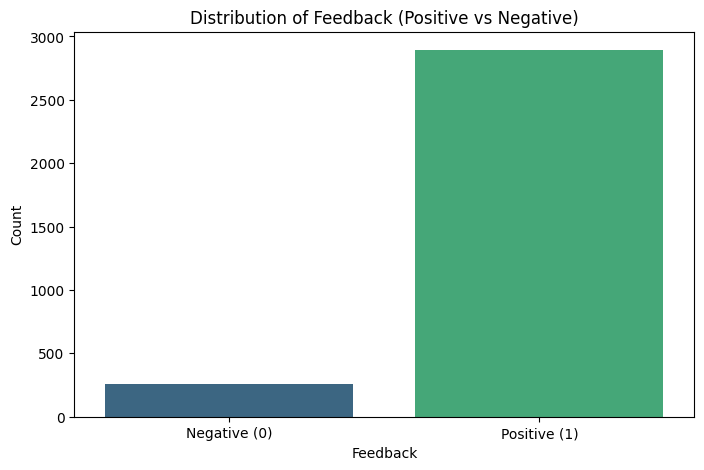

In [3]:
# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='feedback', palette='viridis')

plt.title("Distribution of Feedback (Positive vs Negative)")
plt.xlabel("Feedback")
plt.ylabel("Count")
plt.xticks([0, 1], ["Negative (0)", "Positive (1)"])
plt.show()


/tmp/ipykernel_1290/1892180492.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='variation', y='rating', palette='mako')


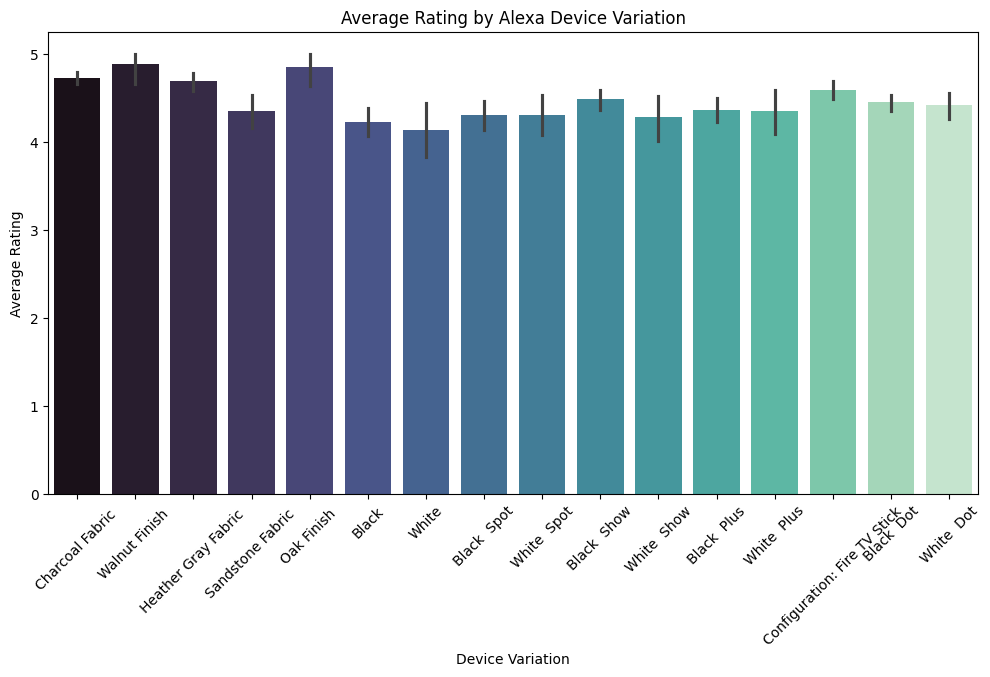

In [4]:
# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=df, x='variation', y='rating', palette='mako')

plt.title("Average Rating by Alexa Device Variation")
plt.xlabel("Device Variation")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()



In [5]:
# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns
# Drop irrelevant columns
df = df.drop(['date', 'rating'], axis=1)
df.head()
df.columns


Index(['variation', 'verified_reviews', 'feedback'], dtype='object')

In [6]:
# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function

# One-Hot Encoding for the 'variation' column
variation_dummies = pd.get_dummies(df['variation'], prefix='variation')

# Add encoded columns to the dataframe
df = pd.concat([df, variation_dummies], axis=1)

# drop the original 'variation' column
df.drop('variation', axis=1, inplace=True)



In [7]:
# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text

from sklearn.feature_extraction.text import CountVectorizer

# Check Missing value
df['verified_reviews'].isna().sum()

# drop Missing value
df = df.dropna(subset=['verified_reviews'])

df['verified_reviews'] = df['verified_reviews'].astype(str)

# Initialize CountVectorizer
cv = CountVectorizer(stop_words='english')

# Fit  and transform the entire 'verified_reviews' column
X_cv = cv.fit_transform(df['verified_reviews'])

# Check the shape
print("Shape:", X_cv.shape)


Shape: (3149, 3784)


In [8]:
# TODO: Combine tokenized reviews with the main dataframe
# Hint: Use pd.concat() to join the dataframes
# Combine with main dataframe

# Convert sparse matrix to a DataFrame
cv_df = pd.DataFrame(X_cv.toarray(), columns=cv.get_feature_names_out())

df_combined = pd.concat([df.reset_index(drop=True), cv_df], axis=1)

# Drop The original verified_reviews column
df_combined = df_combined.drop(['verified_reviews'], axis=1)

# Keep only the first 'feedback' column
df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]


In [9]:
# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'

# Define x and Y
X = df_combined.drop('feedback', axis=1)

y = df_combined['feedback']

In [10]:
# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection

from sklearn.model_selection import train_test_split

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (2519, 3799)
Testing set shape: (630, 3799)


In [11]:
# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training complete.")


Random Forest training complete.


In [12]:
# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Detailed report
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
print(confusion_matrix(y_test, y_pred_rf))


Accuracy: 0.9111111111111111
              precision    recall  f1-score   support

           0       0.62      0.29      0.39        63
           1       0.93      0.98      0.95       567

    accuracy                           0.91       630
   macro avg       0.77      0.63      0.67       630
weighted avg       0.89      0.91      0.90       630

[[ 18  45]
 [ 11 556]]


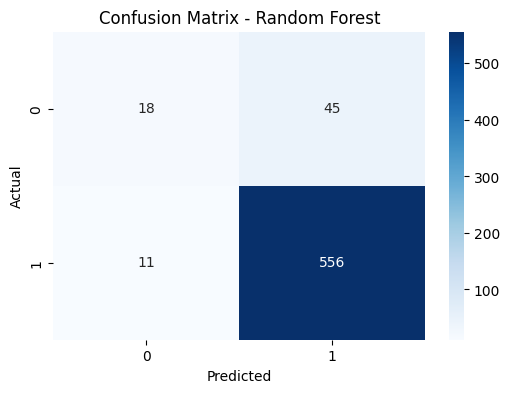

In [13]:
# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [14]:
# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.62      0.29      0.39        63
           1       0.93      0.98      0.95       567

    accuracy                           0.91       630
   macro avg       0.77      0.63      0.67       630
weighted avg       0.89      0.91      0.90       630



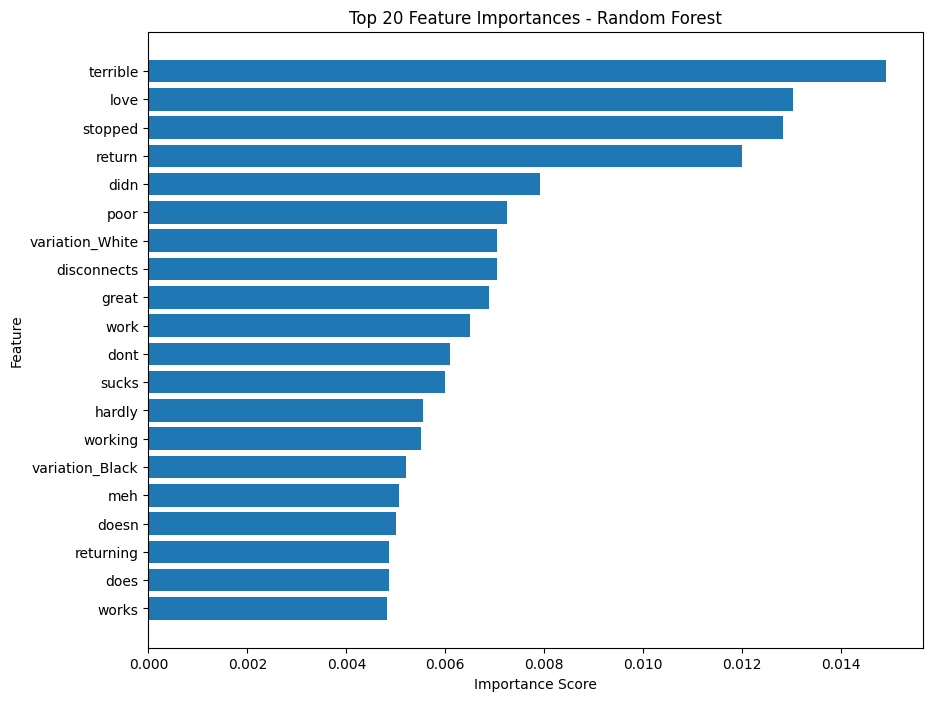

In [15]:
# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances
importances = rf_model.feature_importances_

# Match importances with feature names
feature_names = X_train.columns
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort by importance
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10,8))
plt.barh(feat_imp_df['feature'][:20], feat_imp_df['importance'][:20])
plt.gca().invert_yaxis()  # Highest at top
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [16]:
# TODO: Make predictions on new data
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

def predict_sentiment(review_text):
    # 1. Convert to string
    review_text = str(review_text)

    # 2. Vectorize using the SAME CountVectorizer
    review_cv = cv.transform([review_text])

    # 3. Convert to DataFrame with correct feature names
    review_df = pd.DataFrame(review_cv.toarray(), columns=cv.get_feature_names_out())

    # 4. Create a full row with all training columns
    full_row = pd.DataFrame(0, index=[0], columns=X_train.columns)

    # 5. Insert the review's token values into matching columns
    for col in review_df.columns:
        if col in full_row.columns:
            full_row[col] = review_df[col].values[0]

    # 6. Predict using trained Random Forest model
    prediction = rf_model.predict(full_row)[0]

    # 7. Convert numeric prediction to label
    return "Positive" if prediction == 1 else "Negative"


In [17]:
# Example usage of your prediction function:
# new_review = "I love my Alexa device! It's so helpful."

new_review = "I love my Alexa device! It's so helpful."
predicted_sentiment = predict_sentiment(new_review)
print(f"The sentiment of the new review is: {predicted_sentiment}")


The sentiment of the new review is: Positive
